# CS4305 Artificial Intelligence — Lab 6
## Blind (Uninformed) Search

**What you will learn today**
1. **Breadth-First Search (BFS)** — level by level, using a **queue**
2. **Depth-First Search (DFS)** — go deep first, using a **stack**
3. **Depth-Limited** and **Iterative Deepening** search
4. **Uniform-Cost Search (UCS)** — always the cheapest path first
5. Compare them on a real map

*Blind* means the search has **no idea where the goal is**; it only knows how to move and how to recognise the goal.

**How to use this notebook**
- 📊 **Visual explanation** cells already show a picture. Look at the picture first, then read the code.
- 💻 **Code** cells: click inside and press **Shift + Enter** to run them, from top to bottom.
- 📝 **Lab tasks** are at the end.

In [ ]:
#@title ⚙️ Diagram tools (only needed if you want to redraw the pictures)
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyBboxPatch, Rectangle

PURPLE, ORANGE, TEAL, ROSE, DARK = "#5B2A86", "#FF9F1C", "#1FA898", "#D1495B", "#1A1333"
LIGHT, GREY, WHITE = "#F3EEFA", "#A9A3B8", "#FFFFFF"
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 12})

def tree_layout(children, root, gap=1.0):
    """Tidy layout for a tree given as {parent: [children]}."""
    pos, nxt = {}, [0.0]
    def walk(n, d):
        kids = children.get(n, [])
        if not kids:
            pos[n] = (nxt[0], -d); nxt[0] += gap
        else:
            for k in kids: walk(k, d + 1)
            xs = [pos[k][0] for k in kids]
            pos[n] = ((min(xs) + max(xs)) / 2, -d)
    walk(root, 0)
    return pos

def draw_graph(ax, pos, edges, directed=False, weights=None, colors=None, path=None, r=0.28,
               fs=13, label_below=False, badges=None, badge_color=ORANGE, edge_fs=11, names=None):
    """Draw nodes (circles) and edges. path = list of nodes to highlight in orange."""
    colors = colors or {}
    on_path = set()
    if path:
        for a, b in zip(path, path[1:]): on_path |= {(a, b), (b, a)}
    for i, (a, b) in enumerate(edges):
        (x1, y1), (x2, y2) = pos[a], pos[b]
        L = math.hypot(x2 - x1, y2 - y1); ux, uy = (x2 - x1) / L, (y2 - y1) / L
        s, e = (x1 + ux * r, y1 + uy * r), (x2 - ux * r, y2 - uy * r)
        hi = (a, b) in on_path
        ax.annotate("", xy=e, xytext=s, arrowprops=dict(arrowstyle="-|>" if directed else "-",
                    color=ORANGE if hi else GREY, lw=4 if hi else 1.8, shrinkA=0, shrinkB=0,
                    mutation_scale=18), zorder=1)
        if weights:
            w = weights[i]
            ax.text((x1 + x2) / 2, (y1 + y2) / 2, str(w), ha="center", va="center", fontsize=edge_fs,
                    color=DARK, fontweight="bold", zorder=4,
                    bbox=dict(boxstyle="round,pad=0.2", fc=WHITE, ec="none"))
    for n, (x, y) in pos.items():
        c = colors.get(n, PURPLE)
        ax.add_patch(Circle((x, y), r, fc=c, ec=WHITE, lw=2, zorder=3))
        text = (names or {}).get(n, n)
        if label_below:
            ax.text(x, y - r - 0.06, text, ha="center", va="top", fontsize=fs, color=DARK, fontweight="bold", zorder=5)
        else:
            ax.text(x, y, text, ha="center", va="center", fontsize=fs, color=WHITE if c not in (ORANGE, LIGHT, WHITE) else DARK,
                    fontweight="bold", zorder=5)
    if badges:
        for n, t in badges.items():
            x, y = pos[n]
            ax.add_patch(Circle((x + r * 0.95, y + r * 0.95), r * 0.55, fc=badge_color, ec=WHITE, lw=1.5, zorder=6))
            ax.text(x + r * 0.95, y + r * 0.95, str(t), ha="center", va="center", fontsize=fs - 3,
                    color=DARK, fontweight="bold", zorder=7)
    xs = [p[0] for p in pos.values()]; ys = [p[1] for p in pos.values()]
    m = r * 2.2
    ax.set_xlim(min(xs) - m, max(xs) + m); ax.set_ylim(min(ys) - m - (0.35 if label_below else 0), max(ys) + m)
    ax.set_aspect("equal"); ax.axis("off")

def box(ax, x, y, w, h, text, fc=PURPLE, tc=WHITE, fs=13, bold=True, ec=None, round_=True):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.08" if round_ else "square,pad=0",
                                fc=fc, ec=ec or fc, lw=1.5, zorder=2))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fs, color=tc,
            fontweight="bold" if bold else "normal", zorder=3)

def arrow(ax, x1, y1, x2, y2, color=DARK, lw=2, text=None, fs=11):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw, shrinkA=0, shrinkB=0, mutation_scale=16))
    if text:
        ax.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.12, text, ha="center", va="bottom", fontsize=fs, color=DARK)

def board(ax, x0, y0, state, size=0.9, title=None, highlight=None, fc=LIGHT):
    """Draw an 8-puzzle board. state = string like '123456780' (0 = blank)."""
    highlight = highlight or {}
    for i, ch in enumerate(state):
        r, c = divmod(i, 3)
        x, y = x0 + c * size, y0 - r * size
        blank = ch == "0"
        ax.add_patch(Rectangle((x, y), size, size, fc=WHITE if blank else highlight.get(ch, fc),
                               ec=DARK, lw=2, zorder=2))
        if not blank:
            ax.text(x + size / 2, y + size / 2, ch, ha="center", va="center", fontsize=20, fontweight="bold",
                    color=WHITE if highlight.get(ch) in (PURPLE, ROSE, TEAL) else DARK, zorder=3)
    if title:
        ax.text(x0 + 1.5 * size, y0 + size + 0.25, title, ha="center", va="bottom", fontsize=14, fontweight="bold", color=DARK)

def finish(fig, title=None):
    if title:
        fig.suptitle(title, fontsize=16, fontweight="bold", color=DARK)
    fig.tight_layout()


# ---- shared data for this lab's diagrams ----
def _map():
    roads = [("Peshawar", "Islamabad", 185), ("Peshawar", "Kohat", 65), ("Kohat", "Mianwali", 190),
             ("Islamabad", "Murree", 60), ("Islamabad", "Sargodha", 230), ("Islamabad", "Gujranwala", 225),
             ("Islamabad", "Lahore", 375), ("Mianwali", "Sargodha", 145), ("Sargodha", "Faisalabad", 95),
             ("Sargodha", "Lahore", 190), ("Gujranwala", "Lahore", 70), ("Gujranwala", "Sialkot", 55),
             ("Lahore", "Faisalabad", 180), ("Lahore", "Multan", 340), ("Faisalabad", "Multan", 240)]
    coords = {"Peshawar": (71.58, 34.01), "Kohat": (71.44, 33.58), "Islamabad": (73.05, 33.68),
              "Murree": (73.39, 33.91), "Mianwali": (71.53, 32.58), "Sargodha": (72.67, 32.08),
              "Gujranwala": (74.19, 32.16), "Sialkot": (74.53, 32.49), "Lahore": (74.34, 31.55),
              "Faisalabad": (73.08, 31.42), "Multan": (71.52, 30.16)}
    return roads, coords

def _layout():
    """Schematic (not-to-scale) positions so the map is easy to read."""
    return {"Peshawar": (0, 6), "Kohat": (0, 4.2), "Islamabad": (3, 6), "Murree": (5, 7), "Mianwali": (0.6, 2.2),
            "Sargodha": (2.8, 3), "Gujranwala": (6, 4.4), "Sialkot": (8, 5.2), "Lahore": (6.2, 2.2),
            "Faisalabad": (3.6, 1.0), "Multan": (2.4, -0.8)}

TREE = {"A": ["B", "C"], "B": ["D", "E"], "C": ["F", "G"], "D": ["H"], "E": ["I"]}

def _order_tree(order, title, note):
    pos = tree_layout(TREE, "A", gap=1.3)
    edges = [(p, c) for p, ks in TREE.items() for c in ks]
    fig, ax = plt.subplots(figsize=(10, 5))
    cols = {n: (PURPLE if n in order else LIGHT) for n in pos}
    cols["G"] = ROSE
    draw_graph(ax, pos, edges, directed=True, colors=cols, r=0.3, fs=15,
               badges={n: i + 1 for i, n in enumerate(order)})
    ax.text(pos["A"][0], -3.8, note, ha="center", fontsize=13, color=DARK)
    ax.set_ylim(-4.1, 0.6)
    finish(fig, title)
    return fig

SG = {"pos": {"S": (0, 1), "A": (2, 2.3), "B": (2, -0.1), "C": (4, 1), "G": (6, 1)},
      "edges": [("S", "A"), ("S", "B"), ("A", "B"), ("A", "C"), ("B", "C"), ("C", "G"), ("A", "G")],
      "w": [1, 4, 2, 5, 2, 3, 12], "h": {"S": 6, "A": 5, "B": 3, "C": 2, "G": 0}}
print('Diagram tools ready')

---
## Part 1: Queue vs Stack — the key difference
All blind searches keep a list of places to visit next, called the **frontier**. The only difference is **which one is taken out next**.

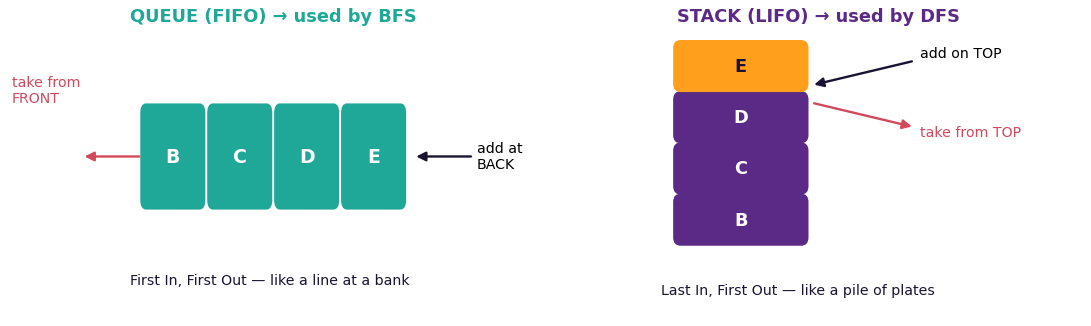

In [ ]:
#@title 📊 Visual explanation: queue (BFS) vs stack (DFS)
def fig_queue_stack():
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
    for i, t in enumerate(["B", "C", "D", "E"]):
        box(a1, 0.5 + i * 1.1, 1.0, 1.0, 0.9, t, fc=TEAL, fs=16)
    arrow(a1, 5.9, 1.45, 5.0, 1.45, color=DARK); a1.text(6.0, 1.45, "add at\nBACK", va="center", fontsize=12)
    arrow(a1, 0.45, 1.45, -0.45, 1.45, color=ROSE); a1.text(-1.65, 2.05, "take from\nFRONT", va="center", fontsize=12, color=ROSE)
    a1.set_title("QUEUE (FIFO) → used by BFS", fontsize=15, fontweight="bold", color=TEAL)
    a1.text(2.6, 0.3, "First In, First Out — like a line at a bank", ha="center", fontsize=12, color=DARK)
    a1.set_xlim(-1.7, 7); a1.set_ylim(0, 2.6); a1.axis("off")
    for i, t in enumerate(["B", "C", "D", "E"]):
        box(a2, 1.5, 0.3 + i * 0.55, 1.6, 0.5, t, fc=ORANGE if i == 3 else PURPLE, tc=DARK if i == 3 else WHITE, fs=15)
    arrow(a2, 4.4, 2.25, 3.2, 2.0, color=DARK); a2.text(4.5, 2.3, "add on TOP", fontsize=12)
    arrow(a2, 3.2, 1.8, 4.4, 1.55, color=ROSE); a2.text(4.5, 1.45, "take from TOP", fontsize=12, color=ROSE)
    a2.set_title("STACK (LIFO) → used by DFS", fontsize=15, fontweight="bold", color=PURPLE)
    a2.text(3.0, -0.25, "Last In, First Out — like a pile of plates", ha="center", fontsize=12, color=DARK)
    a2.set_xlim(0, 6.5); a2.set_ylim(-0.5, 2.6); a2.axis("off")
    finish(fig)
    return fig

fig_queue_stack()
plt.show()

In [ ]:
# ===== Our small example tree (same as the lecture slides) =====
tree = {
    "A": ["B", "C"],
    "B": ["D", "E"],
    "C": ["F", "G"],
    "D": ["H"], "E": ["I"],
    "F": [], "G": [], "H": [], "I": [],
}
print("Children of A:", tree["A"])

---
## Part 2: Breadth-First Search (BFS)
BFS explores **all nodes at depth 1**, then **all at depth 2**, and so on — like ripples in water.

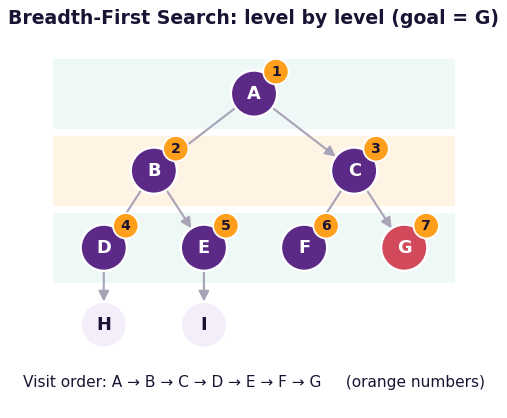

In [ ]:
#@title 📊 Visual explanation: BFS visit order
def fig_bfs_order():
    fig = _order_tree(list("ABCDEFG"), "Breadth-First Search: level by level (goal = G)",
                      "Visit order: A → B → C → D → E → F → G     (orange numbers)")
    ax = fig.axes[0]
    for d, c in [(0, "#EEF8F6"), (1, "#FFF4E3"), (2, "#EEF8F6")]:
        ax.axhspan(-d - 0.45, -d + 0.45, color=c, zorder=0)
    return fig

fig_bfs_order()
plt.show()

Run BFS and check: does the order of `expand` match the orange numbers in the picture?

In [ ]:
# ===== Breadth-First Search (BFS) =====
from collections import deque

def bfs(graph, start, goal):
    frontier = deque([[start]])        # a QUEUE of paths (FIFO)
    explored = set()
    step = 0
    while frontier:
        path = frontier.popleft()      # take from the FRONT
        node = path[-1]
        if node in explored:
            continue
        step += 1
        print(f"Step {step}: expand {node:3s} frontier = {[p[-1] for p in frontier]}")
        if node == goal:
            print("Goal found! Path:", " → ".join(path))
            return path
        explored.add(node)
        for child in graph[node]:
            if child not in explored:
                frontier.append(path + [child])   # add at the BACK
    return None

bfs(tree, "A", "G")

---
## Part 3: Depth-First Search (DFS)
DFS goes **as deep as possible** along one branch, then comes back and tries the next branch.

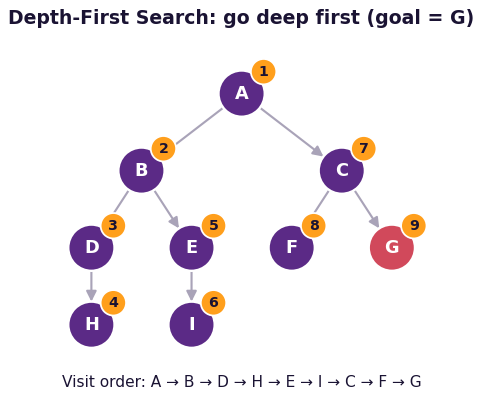

In [ ]:
#@title 📊 Visual explanation: DFS visit order
def fig_dfs_order():
    return _order_tree(list("ABDHEICFG"), "Depth-First Search: go deep first (goal = G)",
                       "Visit order: A → B → D → H → E → I → C → F → G")

fig_dfs_order()
plt.show()

In [ ]:
# ===== Depth-First Search (DFS) =====
def dfs(graph, start, goal):
    frontier = [[start]]               # a STACK of paths (LIFO)
    explored = set()
    step = 0
    while frontier:
        path = frontier.pop()          # take from the TOP
        node = path[-1]
        if node in explored:
            continue
        step += 1
        print(f"Step {step}: expand {node:3s} stack = {[p[-1] for p in frontier]}")
        if node == goal:
            print("Goal found! Path:", " → ".join(path))
            return path
        explored.add(node)
        for child in reversed(graph[node]):   # reversed so the LEFT child is on top
            if child not in explored:
                frontier.append(path + [child])
    return None

dfs(tree, "A", "G")

---
## Part 4: Depth-Limited and Iterative Deepening Search
- **Depth-Limited Search (DLS)**: DFS that is **not allowed to go deeper than a limit**.
- **Iterative Deepening (IDDFS)**: run DLS with limit 0, then 1, then 2 … until the goal is found. It uses little memory like DFS, and finds the shallowest goal like BFS.

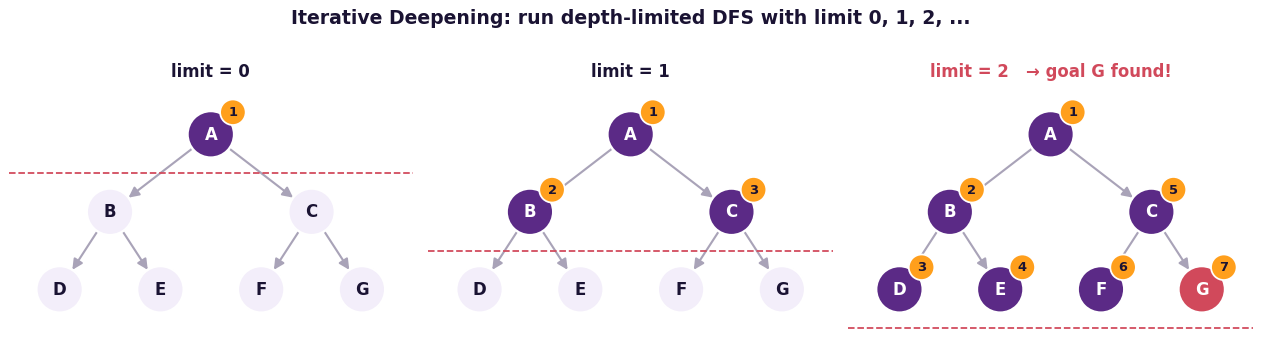

In [ ]:
#@title 📊 Visual explanation: iterative deepening, one limit at a time
def fig_iddfs():
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
    visited = [["A"], ["A", "B", "C"], ["A", "B", "D", "E", "C", "F", "G"]]
    tree = {"A": ["B", "C"], "B": ["D", "E"], "C": ["F", "G"]}
    pos = tree_layout(tree, "A", gap=1.3)
    edges = [(p, c) for p, ks in tree.items() for c in ks]
    for L, (ax, v) in enumerate(zip(axes, visited)):
        cols = {n: (PURPLE if n in v else LIGHT) for n in pos}
        if "G" in v: cols["G"] = ROSE
        draw_graph(ax, pos, edges, directed=True, colors=cols, r=0.3, fs=14, badges={n: i + 1 for i, n in enumerate(v)})
        ax.axhline(-L - 0.5, color=ROSE, ls="--", lw=1.5)
        ax.set_title(f"limit = {L}" + ("   → goal G found!" if L == 2 else ""), fontsize=14, fontweight="bold",
                     color=ROSE if L == 2 else DARK)
    finish(fig, "Iterative Deepening: run depth-limited DFS with limit 0, 1, 2, ...")
    return fig

fig_iddfs()
plt.show()

In [ ]:
# ===== Depth-Limited Search (DLS) and Iterative Deepening (IDDFS) =====
def dls(graph, node, goal, limit, path=None, visited=None):
    path = (path or []) + [node]
    visited.append(node)
    if node == goal:
        return path
    if limit == 0:
        return None                      # cut off: not allowed to go deeper
    for child in graph[node]:
        found = dls(graph, child, goal, limit - 1, path, visited)
        if found:
            return found
    return None

def iddfs(graph, start, goal, max_depth=10):
    for limit in range(max_depth + 1):
        visited = []
        result = dls(graph, start, goal, limit, visited=visited)
        print(f"limit = {limit}: visited {visited}")
        if result:
            print("Goal found at depth", limit, "→ path:", " → ".join(result))
            return result

iddfs(tree, "A", "G")

---
## Part 5: Uniform-Cost Search (UCS)
When roads have **different lengths**, the path with the fewest roads is not always the shortest. UCS always expands the path with the **lowest total cost so far**, using a **priority queue**.

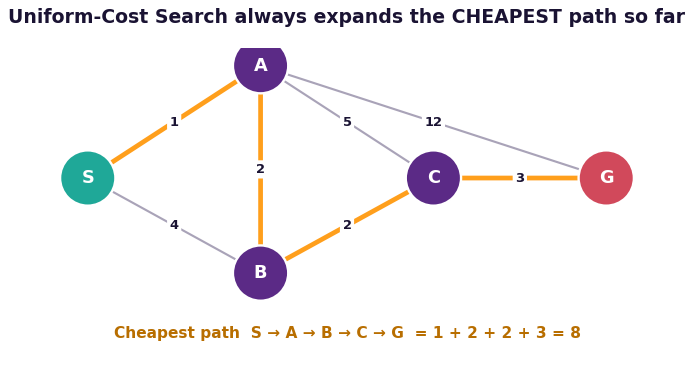

In [ ]:
#@title 📊 Visual explanation: UCS picks the cheapest path
def fig_ucs_graph():
    fig, ax = plt.subplots(figsize=(10, 4.4))
    draw_graph(ax, SG["pos"], SG["edges"], weights=SG["w"], colors={"S": TEAL, "G": ROSE},
               path=["S", "A", "B", "C", "G"], r=0.32, fs=15)
    ax.text(3, -0.85, "Cheapest path  S → A → B → C → G  = 1 + 2 + 2 + 3 = 8", ha="center", fontsize=13,
            fontweight="bold", color="#B86E00")
    ax.set_ylim(-1.1, 2.5)
    finish(fig, "Uniform-Cost Search always expands the CHEAPEST path so far")
    return fig

fig_ucs_graph()
plt.show()

In [ ]:
# ===== Now a real problem: the city map from Lecture 5 =====
roads = {
    "Peshawar":   {"Islamabad": 185, "Kohat": 65},
    "Kohat":      {"Peshawar": 65, "Mianwali": 190},
    "Islamabad":  {"Peshawar": 185, "Murree": 60, "Sargodha": 230, "Gujranwala": 225, "Lahore": 375},
    "Murree":     {"Islamabad": 60},
    "Mianwali":   {"Kohat": 190, "Sargodha": 145},
    "Sargodha":   {"Islamabad": 230, "Mianwali": 145, "Faisalabad": 95, "Lahore": 190},
    "Gujranwala": {"Islamabad": 225, "Lahore": 70, "Sialkot": 55},
    "Sialkot":    {"Gujranwala": 55},
    "Lahore":     {"Islamabad": 375, "Gujranwala": 70, "Sargodha": 190, "Faisalabad": 180, "Multan": 340},
    "Faisalabad": {"Sargodha": 95, "Lahore": 180, "Multan": 240},
    "Multan":     {"Faisalabad": 240, "Lahore": 340},
}
neighbours = {city: list(nbrs) for city, nbrs in roads.items()}   # unweighted version for BFS/DFS

def path_cost(path):
    return sum(roads[a][b] for a, b in zip(path, path[1:]))
print("Map loaded:", len(roads), "cities")

In [ ]:
# ===== Uniform-Cost Search (UCS) =====
import heapq

def ucs(graph, start, goal, verbose=True):
    frontier = [(0, [start])]            # a PRIORITY QUEUE ordered by path cost
    explored = set()
    step = 0
    while frontier:
        cost, path = heapq.heappop(frontier)    # take the CHEAPEST path
        node = path[-1]
        if node in explored:
            continue
        step += 1
        if verbose:
            print(f"Step {step}: expand {node:11s} cost so far = {cost}")
        if node == goal:
            return path, cost, step
        explored.add(node)
        for child, d in graph[node].items():
            if child not in explored:
                heapq.heappush(frontier, (cost + d, path + [child]))
    return None, None, step

path, cost, _ = ucs(roads, "Peshawar", "Multan")
print("\nUCS path:", " → ".join(path), "| cost =", cost, "km")

---
## Part 6: Compare BFS, DFS and UCS on the map
Watch three things: **how many roads** the path uses, **how many km** it is, and **which algorithm finds the shortest route**.

In [ ]:
# ===== Compare the algorithms on the map (Peshawar → Multan) =====
import io, contextlib

def quiet(fn, *args):
    """Run a search without printing its steps; return (result, number of steps printed)."""
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        result = fn(*args)
    steps = sum(1 for line in buf.getvalue().splitlines() if line.startswith(("Step", "limit")))
    return result, steps

p_bfs, n_bfs = quiet(bfs, neighbours, "Peshawar", "Multan")
p_dfs, n_dfs = quiet(dfs, neighbours, "Peshawar", "Multan")
p_ucs, c_ucs, n_ucs = ucs(roads, "Peshawar", "Multan", verbose=False)

print(f"{'Algorithm':9s} | {'Steps':5s} | {'Roads':6s} | {'Km':5s} | Path")
print("-" * 95)
for name, p, n in [("BFS", p_bfs, n_bfs), ("DFS", p_dfs, n_dfs), ("UCS", p_ucs, n_ucs)]:
    print(f"{name:9s} | {n:5d} | {len(p)-1:6d} | {path_cost(p):5d} | {' → '.join(p)}")

In [ ]:
# ===== Draw the three paths on the map =====
import matplotlib.pyplot as plt
pos = {"Peshawar": (0, 6), "Kohat": (0, 4.2), "Islamabad": (3, 6), "Murree": (5, 7), "Mianwali": (0.6, 2.2),
       "Sargodha": (2.8, 3), "Gujranwala": (6, 4.4), "Sialkot": (8, 5.2), "Lahore": (6.2, 2.2),
       "Faisalabad": (3.6, 1.0), "Multan": (2.4, -0.8)}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (name, p) in zip(axes, [("BFS", p_bfs), ("DFS", p_dfs), ("UCS", p_ucs)]):
    for a in roads:
        for b in roads[a]:
            ax.plot(*zip(pos[a], pos[b]), color="#CCCCCC", lw=1.5, zorder=1)
    ax.plot(*zip(*[pos[c] for c in p]), color="#FF9F1C", lw=5, zorder=2)
    for c, (x, y) in pos.items():
        ax.scatter(x, y, s=260, color="#1FA898" if c == "Peshawar" else "#D1495B" if c == "Multan" else "#5B2A86", zorder=3)
        ax.text(x, y - 0.45, c, ha="center", fontsize=9)
    ax.set_title(f"{name}: {path_cost(p)} km, {len(p)-1} roads", fontsize=14, fontweight="bold")
    ax.axis("off")
plt.tight_layout(); plt.show()

**What did you notice?**
- **BFS** finds the path with the **fewest roads** (not the fewest km).
- **DFS** finds *a* path, but it can be long.
- **UCS** finds the **cheapest** path in km.

---
## 📝 Lab Tasks
1. Run BFS and DFS on `tree` with goal **"I"**. Which one finds it first (fewer steps)? Why?
2. Change the DFS so it takes the **right** child first (remove `reversed`). How does the order change?
3. Run `iddfs(tree, "A", "H")`. At which limit is H found?
4. Use UCS to find the cheapest route from **Sialkot to Multan**. Show the path and cost.
5. **Think:** why does BFS need much more memory than DFS on a very big tree?